<a href="https://colab.research.google.com/github/erdijova/Practical-Statistics-for-Data-Scientists/blob/main/Chapter_1_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 1: Exploratory Data Analysis (EDA)

This notebook provides a comprehensive introduction to Exploratory Data Analysis (EDA) based on *Practical Statistics for Data Scientists*. The goal is to deeply understand data before applying any machine learning model.

## Introduction

Exploratory Data Analysis (EDA) is the process of examining datasets to summarize their main characteristics.

EDA helps to:
- Understand data structure
- Detect missing values
- Identify patterns and relationships
- Detect anomalies or outliers

EDA is essential because poor understanding of data leads to poor models.

## Import Libraries

We begin by importing the necessary libraries for data manipulation and visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

We use a sample dataset (`tips`) which contains information about restaurant bills.

You can replace this dataset with your own dataset.

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv')
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## Data Overview

Understanding the structure of the dataset is critical.

We examine:
- Data types
- Number of entries
- Missing values

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB


In [4]:
df.shape

(244, 7)

In [5]:
df.isnull().sum()

,0
total_bill,0
tip,0
sex,0
smoker,0
day,0
time,0
size,0


## Summary Statistics

Summary statistics provide a quick overview of numerical features.

Important metrics:
- Mean (average)
- Median (middle value)
- Standard deviation (spread)
- Min and Max

In [6]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [7]:
print('Mean:', df['total_bill'].mean())
print('Median:', df['total_bill'].median())

Mean: 19.78594262295082
Median: 17.795


In [8]:
print('Variance:', df['total_bill'].var())
print('Std Dev:', df['total_bill'].std())

Variance: 79.25293861397826
Std Dev: 8.902411954856856


## Distribution Analysis

Understanding how data is distributed helps identify skewness and patterns.

We use:
- Histogram
- Density plot
- Boxplot

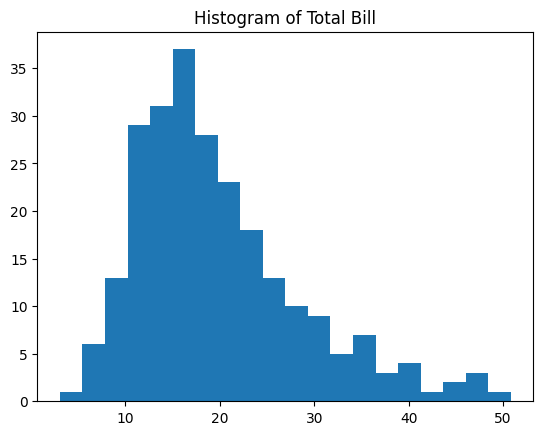

In [9]:
plt.hist(df['total_bill'], bins=20)
plt.title('Histogram of Total Bill')
plt.show()

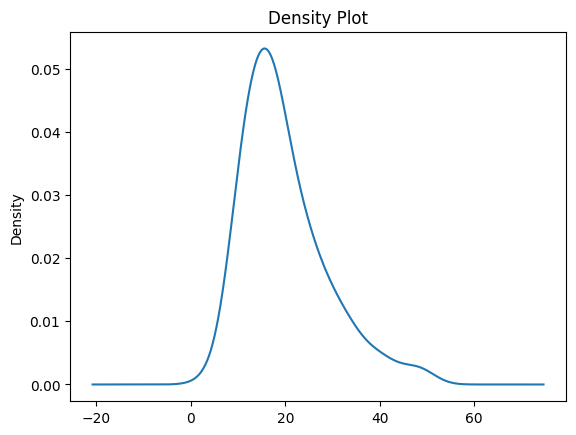

In [10]:
df['total_bill'].plot(kind='density')
plt.title('Density Plot')
plt.show()

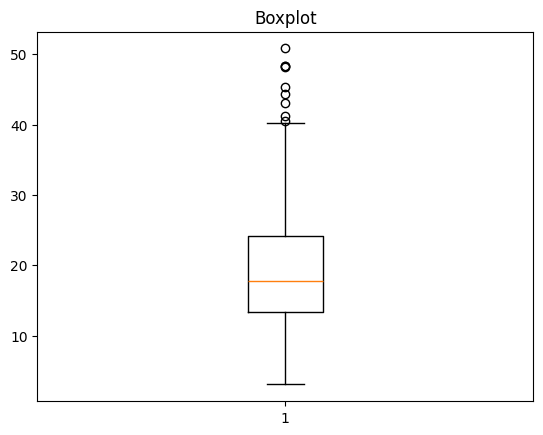

In [11]:
plt.boxplot(df['total_bill'])
plt.title('Boxplot')
plt.show()

## Outlier Detection

Outliers are extreme values that can distort analysis.

We use the IQR (Interquartile Range) method:
- Q1 = 25th percentile
- Q3 = 75th percentile
- IQR = Q3 - Q1

In [12]:
Q1 = df['total_bill'].quantile(0.25)
Q3 = df['total_bill'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['total_bill'] < lower) | (df['total_bill'] > upper)]
outliers

,total_bill,tip,sex,smoker,day,time,size
59,48.27,6.73,Male,No,Sat,Dinner,4
102,44.30,2.50,Female,Yes,Sat,Dinner,3
142,41.19,5.00,Male,No,Thur,Lunch,5
156,48.17,5.00,Male,No,Sun,Dinner,6
170,50.81,10.00,Male,Yes,Sat,Dinner,3
182,45.35,3.50,Male,Yes,Sun,Dinner,3
184,40.55,3.00,Male,Yes,Sun,Dinner,2
197,43.11,5.00,Female,Yes,Thur,Lunch,4
212,48.33,9.00,Male,No,Sat,Dinner,4


## Categorical Data Analysis

Categorical variables represent groups.

We analyze them using:
- Value counts
- Bar charts

In [13]:
df['day'].value_counts()

,count
day,
Sat,87
Sun,76
Thur,62
Fri,19


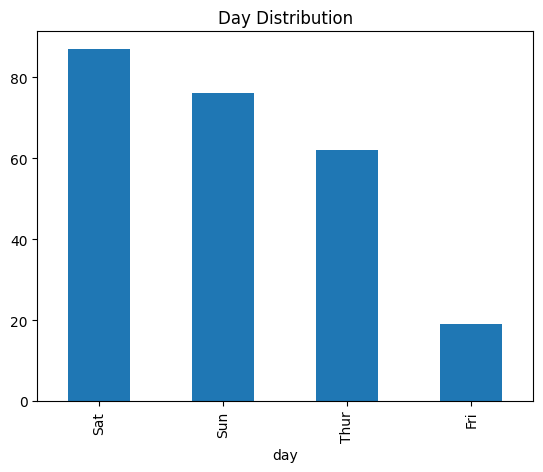

In [14]:
df['day'].value_counts().plot(kind='bar')
plt.title('Day Distribution')
plt.show()

## Relationship Between Variables

We analyze relationships between variables using:
- Scatter plots
- Correlation matrix

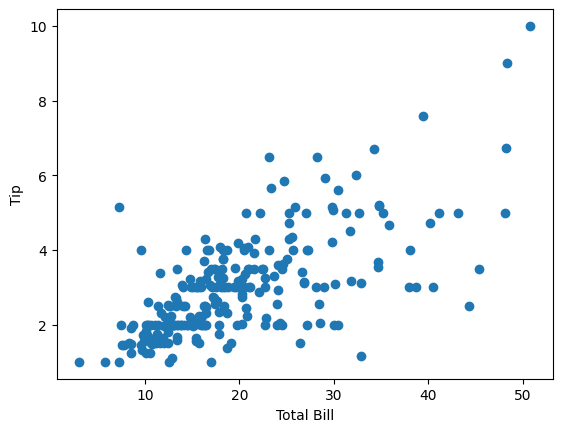

In [15]:
plt.scatter(df['total_bill'], df['tip'])
plt.xlabel('Total Bill')
plt.ylabel('Tip')
plt.show()

In [16]:
df[['total_bill','tip']].corr()

,total_bill,tip
total_bill,1.000000,0.675734
tip,0.675734,1.000000


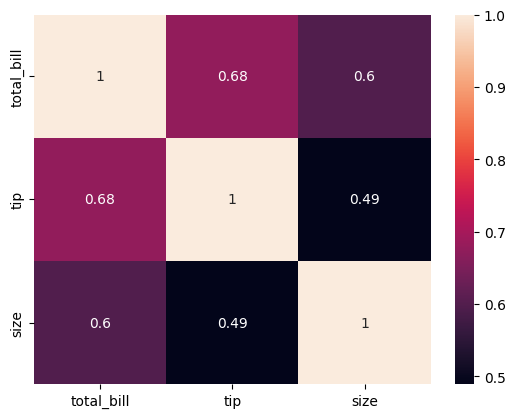

In [17]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

## Group Analysis

Grouping allows comparison across categories.

Example: average bill per day

In [18]:
df.groupby('day')['total_bill'].mean()

,total_bill
day,
Fri,17.151579
Sat,20.441379
Sun,21.410000
Thur,17.682742


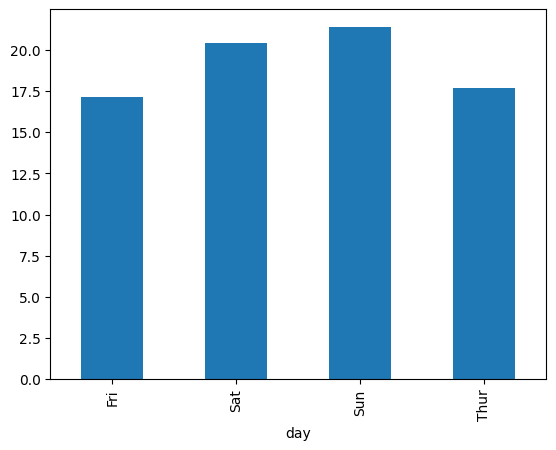

In [19]:
df.groupby('day')['total_bill'].mean().plot(kind='bar')
plt.show()

## Conclusion

In this notebook, we explored:
- Data structure and types
- Summary statistics
- Distribution analysis
- Outlier detection
- Relationships between variables

EDA is a critical step before building any predictive model.